# Universität Osnabrück - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Universität Osnabrück' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/04qmmjx98' -- 'Universität Osnabrück'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Universität Osnabrück,"Ass. iur. Marcel Patric Iden, M.Sc. M.A. is a ...",https://openalex.org/W4313259016
1,not assigned,Universität Osnabrück,Institute for Psychology University of Osnabrü...,https://openalex.org/W4210765253
2,not assigned,Universität Osnabrück,"Osnabrück University, Accounting and Informati...",https://openalex.org/W4301185598
3,not assigned,Universität Osnabrück,"Osnabrück University, Accounting and Informati...",https://openalex.org/W4301185598
4,not assigned,Universität Osnabrück,"Abt. Mikrobiologie, Universität Osnabrück, Osn...",https://openalex.org/W4311929035


In [760]:
MAPPING_DICT = {
    'Fachbereich Biologie / Chemie': ['dida(c|k)ti(k|cs) (of|der) (biolog(ie|y)|chemie)', 'genetics', 'biolog(ie|y)(/| and )chemi(e|stry)', 'botan(y|ical)', 
                                      '(new|organic|neuer) material(ien|s)', '(neuro|mi(k|c)ro)biolog(ie|y)', 'chemi(e|stry)', 'electrochemical',
                                      'bioorganische', '(behavio(u)?ral|structural|cell) biology', 'nanoanalytic', 'zoology', 'biodiversity',
                                      'plant physiology', 'department of ecology', 'animal', '(department|faculty) of biology', 'bioimaging',
                                      'biology didactics', 'biologiedidaktik'
                                     ],
    'Fachbereich Erziehungs- und Kulturwissenschaften': ['education(al)? science', 'erziehungswissenschaft', '(school|science|institute) of education', 
                                                         '(islami(sche|c)|katholische|ev.|evangelische) theolog(ie|y)', 'vocational',
                                                         '(schul|wirtschafts)pädagogik', 'sport', 'elementary education', 'musi(k|c)'
                                                        ],
    'Fachbereich Humanwissenschaften': ['kognitionswissenschaft', 'dermatolog(ie|ic|y|ische)', 'psycholog(ie|y)', 'cognitive', '(human|health) (sciences|research)',
                                        'pflegewissenschaft', 'philosophy', 'ethics and critical theories', 'new public health', 'psychotherapy',
                                        'gesundheitsforschung', 'childhood', 'nursing science', 'forschungsmethodik'
                                       ],
    'Fachbereich Kultur- und Sozialwissenschaften': ['(social|political|soil) science', 'geograph(ie|y)', 'sozial(- und kultur)?wissenschaft', 'european integration',
                                                     'conflict research', 'historisches seminar', 'department of history', 'modern history',
                                                     'neueste geschichte', 'mehrebenenpolitik'
                                                    ],
    'Fachbereich Mathematik / Informatik / Physik': ['mathemati(k|cs)', '(institut|department) (für|of) (physi(k|cs)|informatik)', 'computer science', 'physi(k|cs),',
                                                     'semantic information', 'data science', 'digital image', 'fachbereich physik',
                                                     'software engineering', 'physics (education|department)', 'computer engineering', 'knowledge(-|\s)based systems',
                                                     'artificial intelligence', 'applied algebra', 'comput. sci.'
                                                    ],
    'Fachbereich Rechtswissenschaften': ['(gesellschafts|straf|völker|europa|wirtschafts)recht', 'faculty of law', 'legal studies', 'öffentliches recht'],
    'Fachbereich Sprach- und Literaturwissenschaft': ['germanistik', 'linguistics', 'american studies', 'latinistics', '(romance|latin) (studies|languages)'],
    'Fachbereich Wirtschaftswissenschaften': ['wirtschaftsinformatik', 'business administration', 'accounting', 'economic education', 'business and economics',
                                              'wirtschaftswissenschaften', 'banking and finance', '(international|empirical) economic', 'department of economics',
                                              '(innovation|information) management', 'economic department', 'marketing', 'information systems'
                                             ],
    'Institut für Migrationsforschung und Interkulturelle Studien (IMIS)': ['(imis)', 'migrationsforschung', 'migration research'],
    'Institut für Umweltsystemforschung': ['environmental systems (science|research|economics)'],
    'Universitätsbibliothek': ['university library'],
    #'Zentrum für Informationsmanagement und Virtuelle Lehre': [],
    #'Zentrum für Lehrerbildung (ZLB)': []
}

In [761]:
with open('./mapping_tables_fak/uosnabrueck.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [762]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [763]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [764]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,None,Universität Osnabrück,"Ass. iur. Marcel Patric Iden, M.Sc. M.A. is a ...",https://openalex.org/W4313259016
1,Fachbereich Humanwissenschaften,Universität Osnabrück,Institute for Psychology University of Osnabrü...,https://openalex.org/W4210765253
2,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,"Osnabrück University, Accounting and Informati...",https://openalex.org/W4301185598
3,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,"Osnabrück University, Accounting and Informati...",https://openalex.org/W4301185598
4,Fachbereich Biologie / Chemie,Universität Osnabrück,"Abt. Mikrobiologie, Universität Osnabrück, Osn...",https://openalex.org/W4311929035
...,...,...,...,...
5720,None,Universität Osnabrück,Universität Osnabrück,https://openalex.org/W3006490373
5721,None,Universität Osnabrück,Universität Osnabrück,https://openalex.org/W3139600525
5722,None,Universität Osnabrück,Universität Osnabrück,https://openalex.org/W3047851953
5723,None,Universität Osnabrück,Universität Osnabrück,https://openalex.org/W3004572327


In [765]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()[100:130]

array(['Department of Radiology, Hospital Osnabrueck, Westphalian Wilhelms University of Muenster , Osnabrueck ,',
       'University of Osnabrück, 49084 Osnabrück, Germany,',
       'Osnabrück University  Osnabrück Germany',
       'Plan-Based Robot Control German Research Center for AI (DFKI),Osnabr&#x00FC;ck,Germany',
       'University of Osnabrück, Osnabrück, Deutschland',
       'University of Osnabruck,MTDML, IMM,Osnabruck,Germany',
       'MTDML, IMM, University of Osnabruck, Osnabruck, Germany',
       'University of Osnabrück, Osnabrück, Germany, and Information Society Project, Yale Law School, New Haven, CT, USA',
       'Universität Osnabrück, Albrechtstr. 28a, 49076, Osnabrück, Germany',
       'Osnabrück University Osnabrück Deutschland',
       'Dieser Band bildet den Abschluss eines Projekts, das sich in Zusammenarbeit zwischen der Univer-sität Osnabrück und dem Niedersächsischen Freilichtmuseum Kloppendorf zwischen 2009 und 2012',
       'Nature Robots GmbH,Osnabruck,

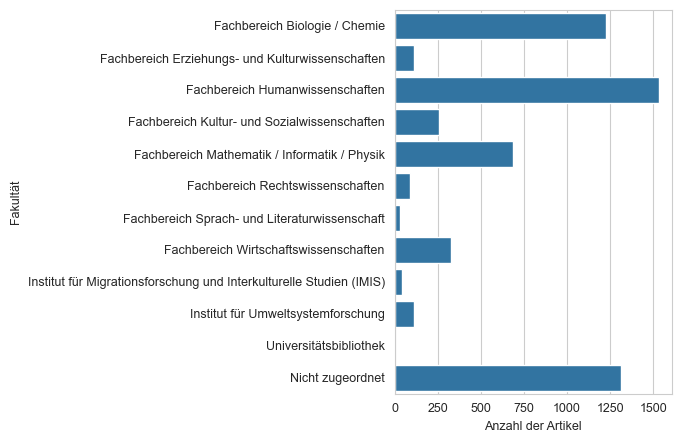

In [766]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [767]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.7706550218340611

In [631]:
MAPPING_DICT_DEPT = {
    'Fachbereich Biologie / Chemie': {
        'Abteilung Mitochondriale Dynamik': ['mitochondriale', 'mitochondrial dynamics'],
        'Arbeitsgruppe Bioanalytische Chemie': ['bioanalytische chemie', 'bioanalytical chemistry'],
        'Arbeitsgruppe Biochemie': ['biochemi(e|stry)'],
        'Arbeitsgruppe Biodiversität und Landschaftsökologie': ['biodiversität', 'biodiversity'],
        'Arbeitsgruppe Biologiedidaktik': ['biologiedidaktik', 'biology didactics', 'didactics of biology'],
        'Arbeitsgruppe Biophysik': ['biophysics'],
        'Arbeitsgruppe Botanik': ['botan(ik|y)'],
        'Arbeitsgruppe Chemische Biologie der Membranen': ['chemische biologie', 'membrane biology'],
        #'Arbeitsgruppe Dynamik der multizellulären Signalgebung': [],
        'Arbeitsgruppe Genetik': ['genetics', 'ag genetik'],
        'Arbeitsgruppe Mikrobiologie': ['(?<!molekulare) mi(k|c)robiolog(ie|y)'],
        'Arbeitsgruppe Molekulare Infektionsbiologie': ['molecular infection biology'],
        'Arbeitsgruppe Molekulare Mikrobiologie': ['molekulare mikrobiologie'],
        'Arbeitsgruppe Molekulare Zellbiologie': ['molecular cell biology'],
        'Arbeitsgruppe Neurobiologie': ['neurobiolog(ie|y)'],
        'Arbeitsgruppe Strukturbiologie': ['structural biology'],
        'Arbeitsgruppe Tierphysiologie': ['animal (nutrition|husbandry)', 'animal physiology', 'tierphysiologie'],
        'Arbeitsgruppe Zoologie-Entwicklungsbiologie': ['developmental biology', 'zoolog(ie|y)'],
        'Arbeitsgruppe Ökologie': ['department of ecology', 'ecology section'],
        'Botanischer Garten': ['botani(sch|cal)'],
        #'Center for Advanced Light Microscopy': [],
        'Institut für Chemie neuer Materialien': ['chemie neuer materialien', 'chemistry of new materials', 'organic materials chemistry', 'chemistry education',
                                                  'didactics of chemistry', 'didaktik der chemie', 'chemiedidaktik', 'bioorganische chemie', '(inorganic|physical) chemistry',
                                                  'electrochemical'
                                                 ],
        'Labor für zelluläre Kommunikation': ['cellular communication'],
        'Lehrstuhl Pflanzenphysiologie': ['plant physiology'],
        'Verhaltensbiologie': ['verhaltensbiologie', 'behavio(u)?ral biology'],
        'Center of Cellular Nanoanalytics': ['cent(er|re) (of|for) cellular nanoanalytic', 'cellnanos', 'bioimaging'] # selbst ergänzt
    },
    'Fachbereich Erziehungs- und Kulturwissenschaften': {
        'Fachgebiet Sachuntericht': ['sachuntericht'],
        'Institut für Erziehungswissenschaft': ['erziehungswissenschaft', 'educational science', 'schulpädagogik', 'vocational education'],
        'Institut für Evangelische Theologie': ['ev(.|angelische) theologie'],
        'Institut für Islamische Theologie (IIT)': ['islamische theologie', 'islamic theology'],
        'Institut für Katholische Theologie': ['katholische theologie'],
        'Institut für Musikwissenschaft und Musikpädagogik': ['musikwissenschaft'],
        'Institut für Sport- und Bewegungswissenschaften': ['bewegungswissenschaften', 'sport(s)? and movement', 'human movement'],
        'Studiengang für Islamische Religionspädagogik (IRP)': ['islamische religionspädagogik'],
    },
    'Fachbereich Humanwissenschaften': {
        'Institut für Gesundheitsforschung und Bildung (IGB)': ['gesundheitsforschung', 'dermatolog(i|y)', 'health (research|science)', 'public health', 'nursing science',
                                                                'pflegewissenschaft'
                                                               ],
        'Institut für Kognitionswissenschaft': ['cognitive science', 'kognitionswissenschaft'],
        'Institut für Philosophie': ['philosoph(ie|y)'],
        'Institut für Psychologie': ['psycholog(ie|y)', 'early childhood', 'psychotherapy', 'forschungsmethodik'],
    },
    'Fachbereich Kultur- und Sozialwissenschaften': {
        'Fachgebiet Kunst / Kunstpädagogik': ['kunst'],
        'Fachgebiet Textiles Gestalten': ['textiles gestalten'],
        'Historisches Seminar': ['historisches seminar', 'modern history', 'neueste geschichte', 'department of history'],
        'Institut für Geographie': ['geograph(ie|y)'],
        'Institut Sozialwissenschaften': ['(department|institute) (of|for) social science', 'sozialwissenschaften', 'political science', 'international relations'],
        'Interdisziplinäres Institut für Kulturgeschichte der Frühen Neuzeit': ['neuzeit'],
        'Kunsthistorisches Institut': ['kunsthistorisches institut'],
    },
    'Fachbereich Mathematik / Informatik / Physik': {
        'Fach Physik': ['fach(bereich)? physik', 'physics department', '(faculty|school|department|institute) (of|for) physic', 'institut für physik', 'biophysics',
                        'physics education'
                       ],
        'Institut für Informatik': ['(inst(.|itut(e)?)|dep(artment|.)) (of|for) computer science', 'institut für informatik', '(software|computer) engineering', 
                                    'information system', 'artificial', 'theoretical computer', 'comput.',
                                    'remote sensing', 'knowledge(-|\s)based'
                                   ],
        'Institut für Mathematik': ['mathemati(c|k)', 'algebra'],
    },
    'Fachbereich Rechtswissenschaften': {
        'Center for International Research on Chinese Law and Economics (CIRCLE)': ['chinese law'],
        'Institut für Europäische Rechtswissenschaft': ['europarecht', 'internationales strafrecht', 'verwaltungswissenschaften', 'european', 'international law'],
        'Institut für Finanz- und Steuerrecht': ['steuerrecht'],
        'Institut für Handels- und Wirtschaftsrecht': ['handels- und wirtschaftsrecht', 'bürgerliches recht', 'unternehmens- und wirtschaftsrecht'],
        'Institut für Kommunalrecht': ['kommunalrecht'],
        'Institut für Staats-, Verwaltungs- und Wirtschaftsrecht (ISVWR)': ['institut für staats'],
        'Institut für Verfahrensrecht und allgemeine Verfahrensvergleichung': ['verfahrensrecht'],
        'Institut für Wirtschaftsstrafrecht': ['wirtschaftsstrafrecht', 'steuerstrafrecht'],
    },
    'Fachbereich Sprach- und Literaturwissenschaft': {
        'Institut für Anglistik / Amerikanistik': ['english', 'british', 'anglistik', 'amerikanistik'],
        'Institut für Germanistik (IfG)': ['germanistik'],
        'Institut für Romanistik / Latinistik': ['roman(ce|istics)'],
    },
    'Fachbereich Wirtschaftswissenschaften': {
        'Fach Betriebswirtschaftslehre (BWL)': ['betriebswirtschaftslehre', 'bwl', 'banking', 'innovation management', 'marketing'],
        'Fach Volkswirtschaftslehre (VWL)': ['volkswirtschaftslehre', 'vwl', 'international economic'],
        'Fach Wirtschaftsinformatik (WI)': ['wirtschaftsinformatik', 'business informatics'],
        'Institut für Empirische Wirtschaftsforschung': ['wirtschaftsforschung', 'empiri(sch|cal)'],
        'Institut für Informationsmanagement und Unternehmensführung (IMU)': ['informationsmanagement'],
        'Institut für Umweltsystemforschung': ['environmental', 'umwelt'] #selbst ergänzt
    }
}

In [632]:
with open('./mapping_tables_dept/uosnabrueck.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [633]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [634]:
current_faculty = 'Fachbereich Mathematik / Informatik / Physik'

In [635]:
df_with_inst.loc[df_with_inst['fak_name'] == current_faculty, 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == current_faculty]['raw_affiliation_string'].apply(map_dept, 
                                                                                    faculty=current_faculty)

In [636]:
df_with_inst[(df_with_inst['fak_name'] == current_faculty) & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[0:]

array(['Physics, University Osnabrueck, Barbarastr. 7, D - 49076 Osnabrueck, Germany, Osnabrueck, GERMANY',
       'Physics, University Osnabrueck, Osnabrueck, GERMANY',
       'Physics, University Osnabrueck, Barbarastr. 7, D - 49076 Osnabrueck, Germany, Osnabrueck, D-49076, GERMANY',
       'Physics, University Osnabrueck, Barbarastr. 7, D - 49076 Osnabrueck, Germany, Osnabrueck, D-49069, GERMANY',
       'Physik, University Osnabrück, Osnabrück, Germany, --- Select a Country ---'],
      dtype=object)

In [637]:
df_with_inst[df_with_inst['fak_name'] == current_faculty].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Fach Physik,184
1,Institut für Informatik,340
2,Institut für Mathematik,155
3,NaN,8


In [638]:
df_with_inst[df_with_inst['fak_name'] == current_faculty]

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
8,Fachbereich Mathematik / Informatik / Physik,Universität Osnabrück,"Department of Physics, Osnabrück University, 4...",https://openalex.org/W4221066239,Fach Physik
15,Fachbereich Mathematik / Informatik / Physik,Universität Osnabrück,"Department of Physics, University of Osnabrück...",https://openalex.org/W4307285114,Fach Physik
18,Fachbereich Mathematik / Informatik / Physik,Universität Osnabrück,"University of Osnabrueck,Department of Physics...",https://openalex.org/W4392026238,Fach Physik
19,Fachbereich Mathematik / Informatik / Physik,Universität Osnabrück,"Universität Osnabrück, Fachbereich Physik, Bar...",https://openalex.org/W4296709032,Fach Physik
30,Fachbereich Mathematik / Informatik / Physik,Universität Osnabrück,"Osnabrück University, Institute of Mathematics...",https://openalex.org/W3129102144,Institut für Mathematik
...,...,...,...,...,...
5061,Fachbereich Mathematik / Informatik / Physik,Universität Osnabrück,"Department of Physics, Osnabrück University, O...",https://openalex.org/W3094025272,Fach Physik
5076,Fachbereich Mathematik / Informatik / Physik,Universität Osnabrück,"Institute of Computer Science, University of O...",https://openalex.org/W3106253623,Institut für Informatik
5078,Fachbereich Mathematik / Informatik / Physik,Universität Osnabrück,"Theoretical Computer Science, Osnabrück Univer...",https://openalex.org/W4415141367,Institut für Informatik
5091,Fachbereich Mathematik / Informatik / Physik,Universität Osnabrück,"Fachbereich Mathematik/Informatik/Physik, Univ...",https://openalex.org/W4409191323,Institut für Mathematik


In [745]:
MAPPING_DICT_INST = {
    'Institut für Chemie neuer Materialien': {
        'Forschungsgruppe Funktionale Nanomaterialien': ['nanomaterial'],
        'Mesoskopische Strukturbildung in Nanoporen': ['nano(\s)?pore'],
        'Organische Chemie - Molekulare Elektrochemie': ['mole(k|c)ular'],
        'Organische Materialchemie und Bioorganische Chemie (OMC)': ['bioorgani(sch|c)'],
        'The electrochemical energy and catalysis group': ['catalysis'],
    },
    'Institut für Erziehungswissenschaft': {
        'Abteilung Allgemeine Erziehungswissenschaft, Sozialpädagogik und Frühe Bildung': ['allgemeine erziehung'],
        'Abteilung Berufs- und Wirtschaftspädagogik': ['vocational education', 'wirtschaftspädagogik'],
        'Abteilung Schulpädagogik': ['schulpädagogik'],
        #'Fachgebiet Frühkindliche Bildung/Elementarpädagogik': [],
        #'Fachgebiet für Interkulturelle Pädagogik': [],
        #'Fachgebiet Sozialisation, außerschulische Bildung und Erziehung': [],
    },
    'Institut für Gesundheitsforschung und Bildung (IGB)': {
        'Abteilung Didaktik der Humandienstleistungsberufe': ['dida(k|c)ti(k|c)'],
        'Abteilung New Public Health': ['public health'],
        'Biomedizinische Grundlagen': ['biomedi(zinisch|cal)'],
        'Fachgebiet Dermatologie, Umweltmedizin, Gesundheitstheorie': ['dermatolog(ie|y|ic|isch)'],
        'Fachgebiet Pflegewissenschaft': ['pflegewissenschaft', 'nursing'],
    },
    'Institut für Psychologie': {
        'Fachgebiet Allgemeine Psychologie I': ['(general|experimental) psychology i(?!i)'],
        'Fachgebiet Allgemeine Psychologie II und Biologische Psychologie': ['(general|experimental) psychology ii'],
        'Fachgebiet Arbeits- und Organisationspsychologie': ['organizational psychology', 'organisationspsychologie'],
        'Fachgebiet Differentielle Psychologie und Persönlichkeitsforschung': ['differenti(e|a)l', 'personality'],
        'Fachgebiet Entwicklung und Kultur': ['developmental psychology'],
        'Fachgebiet Forschungsmethodik, Diagnostik und Evaluation': ['research methodology', 'forschungsmethodik', 'diagnosti(k|cs)'],
        'Fachgebiet Klinische Psychologie und Psychotherapie des Kindes- und Jugendalters': ['childhood', 'erwachsen', 'kindes'],
        'Fachgebiet Klinische Psychologie und Psychotherapie': ['psychotherap(ie|y)'],
        'Fachgebiet Psychotherapieforschung und Klinische Psychologie': ['psychotherapieforschung'],
        'Fachgebiet Pädagogische Psychologie': ['educational psychology', 'pädagogische psychologie'],
        'Fachgebiet Sozialpsychologie': ['sozialpsychologie', 'social psychology'],
    },
    'Institut für Informatik': {
        'Arbeitsgruppe Medieninformatik': ['medieninformatik', 'media computer'],
        'Arbeitsgruppe Theoretische Informatik': ['theoreti(sch|cal)'],
        'Arbeitsgruppe Umweltinformatik und Kommunalplanung': ['umweltinformatik', 'environmental'],
        'Lehrstuhl Wissensverarbeitung in hybriden KI-Systemen': ['wissensverarbeitung'],
        'Professur für Semantische Informationssysteme': ['semanti(sch|c)'],
    },
    'Fach Betriebswirtschaftslehre (BWL)': {
        #'Fachgebiet Bilanz-, Steuer- und Prüfungswesen': [],
        'Fachgebiet International Accounting': ['accounting'],
        'Fachgebiet Marketing': ['marketing'],
        'Fachgebiet Rechnungswesen und Controlling': ['controlling'],
        'Lehrstuhl Banken und Finanzierung': ['banking'],
        #'Unternehmensführung und Unternehmensrechnung - Heinrich W. Risken Stiftungslehrstuhl': [],
    },
    'Fach Volkswirtschaftslehre (VWL)': {
        'Fachgebiet Internationale Wirtschaftspolitik': ['international'],
        #'Fachgebiet Mikroökonomik insbes. Informationsökonomik': [],
        #'Fachgebiet VWL/Finanzwissenschaft': [],
    },
    'Fach Wirtschaftsinformatik (WI)': {
        'Fachgebiet BWL / Organisation und Wirtschaftsinformatik (BOW)': ['organi(s|z)ation'],
        'Fachgebiet Informationsmanagement und Wirtschaftsinformatik (IMWI)': ['information(\s|s(-)?)management'],
        'Fachgebiet Management Support und Wirtschaftsinformatik (MSWI)': ['support'],
        'Fachgebiet Unternehmensrechnung und Wirtschaftsinformatik (UWI)': ['unternehmensrechnung'],
    }
}

In [746]:
with open('./mapping_tables_inst/uosnabrück.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_INST, f, ensure_ascii=False)

In [747]:
def map_inst(address: str, department: str) -> Union[str, None]:
    if department in MAPPING_DICT_INST:
        for k, v in MAPPING_DICT_INST.get(department).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [753]:
current_faculty = 'Fachbereich Wirtschaftswissenschaften'
current_department = 'Institut für Empirische Wirtschaftsforschung'

In [754]:
df_with_inst.loc[df_with_inst['fak_name'] == current_faculty, 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == current_faculty]['raw_affiliation_string'].apply(map_dept, 
                                                                                                  faculty=current_faculty)

df_with_inst.loc[df_with_inst['dept_name'] == current_department, 'inst_name'] = \
    df_with_inst.loc[df_with_inst['dept_name'] == current_department]['raw_affiliation_string'].apply(map_inst, 
                                                                                                      department=current_department)

In [755]:
df_with_inst[(df_with_inst['dept_name'] == current_department) & df_with_inst['inst_name'].isnull()].raw_affiliation_string.unique()[:50]

array(['Institute of Empirical Economic Research, Osnabrück University, 49069, Osnabrück, Germany',
       'Osnabrück University, Institute of Empirical Economic Research  Osnabrück Germany',
       'Institute of Empirical Economic Research School of Business Administration and Economics, University of Osnabrueck Osnabrueck Germany',
       'Institute of Empirical Economic Research, School of Business Administration and Economics, University of Osnabrueck, Osnabrueck, Germany',
       'Institute of Empirical Economic Research, Osnabrück University, Neuer Graben/Schloss, 49074 Osnabrück, Germany',
       'Institute of Empirical Economic Research, Osnabrueck University Osnabrueck, Germany',
       'Institute of Empirical Economic Research, Osnabrück University ,',
       'Institute of Empirical Economic Research, Osnabrück University and CESifo, Munich, Germany',
       'Universität Osnabrück - Institute of Empirical Economic Research',
       'Institute of Empirical Economic Research, O

In [756]:
df_with_inst[df_with_inst['dept_name'] == current_department].groupby(['inst_name'], dropna=False)['openalex_id'].count().reset_index()

,inst_name,openalex_id
0,NaN,15


In [757]:
df_with_inst[df_with_inst['dept_name'] == current_department]

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name,inst_name
14,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,"Institute of Empirical Economic Research, Osna...",https://openalex.org/W4290237505,Institut für Empirische Wirtschaftsforschung,None
1014,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,"Osnabrück University, Institute of Empirical E...",https://openalex.org/W4405165954,Institut für Empirische Wirtschaftsforschung,None
1093,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,Institute of Empirical Economic Research Schoo...,https://openalex.org/W4391823408,Institut für Empirische Wirtschaftsforschung,None
1094,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,"Institute of Empirical Economic Research, Scho...",https://openalex.org/W4391823408,Institut für Empirische Wirtschaftsforschung,None
1741,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,"Institute of Empirical Economic Research, Osna...",https://openalex.org/W4410221825,Institut für Empirische Wirtschaftsforschung,None
2355,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,"Institute of Empirical Economic Research, Osna...",https://openalex.org/W7134948916,Institut für Empirische Wirtschaftsforschung,None
2363,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,"Institute of Empirical Economic Research, Osna...",https://openalex.org/W4417069881,Institut für Empirische Wirtschaftsforschung,None
3582,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,"Institute of Empirical Economic Research, Osna...",https://openalex.org/W4206766012,Institut für Empirische Wirtschaftsforschung,None
3731,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,Universität Osnabrück - Institute of Empirical...,https://openalex.org/W4242642214,Institut für Empirische Wirtschaftsforschung,None
3833,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,Universität Osnabrück - Institute of Empirical...,https://openalex.org/W3158791426,Institut für Empirische Wirtschaftsforschung,None


In [758]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Universität Osnabrück'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

uni_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    uni_dicts[faculty] = faculty_dict

with open('../../data/mappings/uosnabrück.json', mode='w', encoding='utf-8') as f:
    json.dump(uni_dicts, f, ensure_ascii=False)